SCENARIO 2: ITEM-BASED CF
NOORIN NASHIKA M - 24BAD084
Item Similarity:
 movie_id       101       102       103       104
movie_id                                        
101       1.000000  0.633248  0.455677  0.688040
102       0.633248  1.000000  0.484774  0.245959
103       0.455677  0.484774  1.000000  0.566365
104       0.688040  0.245959  0.566365  1.000000

Similar Movies to 101:
 movie_id
104    0.688040
102    0.633248
Name: 101, dtype: float64

Recommendations for User 1:
 [(104, 6.123134253795545)]


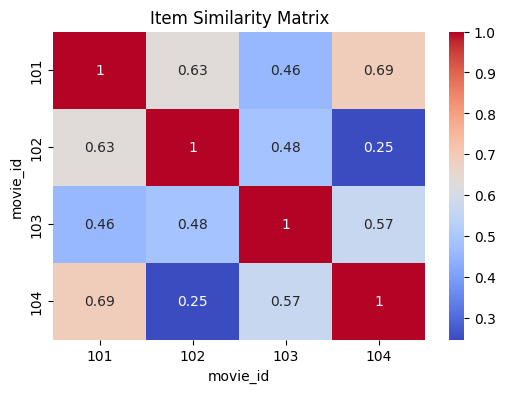

In [1]:
# ==============================
# SCENARIO 2: ITEM-BASED CF
# ==============================
print("SCENARIO 2: ITEM-BASED CF")
print("NOORIN NASHIKA M - 24BAD084")
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Same Dataset
data = {
    'user_id': [1,1,1,2,2,2,3,3,3,4,4,5,5],
    'movie_id': [101,102,103,101,102,104,101,103,104,102,103,101,104],
    'rating': [5,4,3,4,5,2,2,5,4,4,3,5,3]
}

df = pd.DataFrame(data)

# Step 2: Item-User Matrix
item_user = df.pivot_table(index='movie_id', columns='user_id', values='rating')

item_user_filled = item_user.fillna(0)

# Step 3: Item Similarity
item_similarity = cosine_similarity(item_user_filled)

item_sim_df = pd.DataFrame(item_similarity,
                          index=item_user.index,
                          columns=item_user.index)

print("Item Similarity:\n", item_sim_df)

# Step 4: Find Similar Items
def similar_items(item_id, sim_df, n=2):
    return sim_df[item_id].sort_values(ascending=False)[1:n+1]

print("\nSimilar Movies to 101:\n", similar_items(101, item_sim_df))

# Step 5: Recommend for User
user_item = df.pivot_table(index='user_id', columns='movie_id', values='rating')

def recommend_items(user_id, user_item, item_sim_df, n=2):
    user_ratings = user_item.loc[user_id]
    scores = {}

    for item, rating in user_ratings.dropna().items():
        sims = item_sim_df[item]
        for sim_item, sim_score in sims.items():
            if pd.isna(user_item.loc[user_id].get(sim_item)):
                scores[sim_item] = scores.get(sim_item, 0) + sim_score * rating

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]

print("\nRecommendations for User 1:\n", recommend_items(1, user_item, item_sim_df))

# Step 6: Visualization
plt.figure(figsize=(6,4))
sns.heatmap(item_sim_df, annot=True, cmap="coolwarm")
plt.title("Item Similarity Matrix")
plt.show()